# Montréal Gas Price — Notebook 2: Feature Engineering
**Input:** `montreal_gas_features_daily.csv` (output from Notebook 1)
**Output:** `montreal_gas_ml_ready.csv` — fully engineered feature matrix ready for ML

Features built:
- Lag features (gas price & WTI)
- Rolling statistics (mean, std)
- WTI momentum
- Calendar features
- Target variable

**Next:** Notebook 3 — Modelling

## 0. Imports

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3.13 install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

PLOTS_DIR = '../plots'
DATA_DIR  = '../Data'

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 4)
print('Ready.')

Ready.


## 1. Load data

In [3]:
df = pd.read_csv(os.path.join(DATA_DIR, 'montreal_gas_features_daily.csv'))
date_col = 'date' if 'date' in df.columns else 'Unnamed: 0'
df[date_col] = pd.to_datetime(df[date_col])
df = df.set_index(date_col)
df.index.name = 'date'

print(f'Loaded: {len(df):,} rows  {df.index.min().date()} → {df.index.max().date()}')
print('Columns:', df.columns.tolist())
df.head()

Loaded: 2,545 rows  2016-07-01 → 2026-04-01
Columns: ['gas_price', 'wti_usd', 'cadusd', 'wti_cad']


,gas_price,wti_usd,cadusd,wti_cad
date,,,,
2016-07-01,117.9,49.02,1.2897,38.008839
2016-07-04,110.5,49.02,1.2897,38.008839
2016-07-05,109.3,46.73,1.2950,36.084942
2016-07-06,108.2,47.37,1.3003,36.430055
2016-07-07,107.1,45.22,1.2984,34.827480


## 2. Lag features

Lag features give the model access to past values of gas price and WTI.
For example, `gas_lag_1` = yesterday's gas price, `gas_lag_5` = price 5 days ago.

These are typically the strongest predictors in gas price models.

`.shift(n)` shifts values **forward** by n rows — row t gets the value from row t-n
(n days ago). This ensures we never use future data to predict the past.

In [4]:
# Gas price lags
for lag in [1, 2, 3, 5, 10, 21]:
    df[f'gas_lag_{lag}'] = df['gas_price'].shift(lag)

# WTI lags (in CAD — most relevant for Canadian pump prices)
for lag in [1, 2, 5]:
    df[f'wti_cad_lag_{lag}'] = df['wti_cad'].shift(lag)

print('Lag features added.')
df.filter(like='lag')

Lag features added.


,gas_lag_1,gas_lag_2,gas_lag_3,gas_lag_5,gas_lag_10,gas_lag_21,wti_cad_lag_1,wti_cad_lag_2,wti_cad_lag_5
date,,,,,,,,,
2016-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-07-04,117.9,NaN,NaN,NaN,NaN,NaN,38.008839,NaN,NaN
2016-07-05,110.5,117.9,NaN,NaN,NaN,NaN,38.008839,38.008839,NaN
2016-07-06,109.3,110.5,117.9,NaN,NaN,NaN,36.084942,38.008839,NaN
2016-07-07,108.2,109.3,110.5,NaN,NaN,NaN,36.430055,36.084942,NaN
...,...,...,...,...,...,...,...,...,...
2026-03-26,181.8,194.4,194.6,187.5,171.8,152.3,66.316400,67.698344,70.045915
2026-03-27,187.3,181.8,194.4,186.7,176.4,151.2,69.449058,66.316400,71.888428
2026-03-30,182.9,187.3,181.8,194.6,188.3,152.3,72.953890,69.449058,65.118822


## 3. Rolling statistics

Rolling features capture recent trends and volatility over a window of past days.
- **Rolling mean** — smoothed price level over the window
- **Rolling std** — price volatility over the window

We apply `.shift(1)` before rolling to ensure we only use past data — never today's.
`min_periods=1` prevents NaN when the window is not yet full at the start of the series.

In [5]:
for window in [5, 10, 21]:
    df[f'gas_roll_mean_{window}'] = df['gas_price'].shift(1).rolling(window, min_periods=1).mean()
    df[f'gas_roll_std_{window}']  = df['gas_price'].shift(1).rolling(window, min_periods=1).std()

for window in [5, 21]:
    df[f'wti_cad_roll_mean_{window}'] = df['wti_cad'].shift(1).rolling(window, min_periods=1).mean()

print('Rolling features added.')
df.filter(like='roll')

Rolling features added.


,gas_roll_mean_5,gas_roll_std_5,gas_roll_mean_10,gas_roll_std_10,gas_roll_mean_21,gas_roll_std_21,wti_cad_roll_mean_5,wti_cad_roll_mean_21
date,,,,,,,,
2016-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-07-04,117.900000,NaN,117.900000,NaN,117.900000,NaN,38.008839,38.008839
2016-07-05,114.200000,5.232590,114.200000,5.232590,114.200000,5.232590,38.008839,38.008839
2016-07-06,112.566667,4.657610,112.566667,4.657610,112.566667,4.657610,37.367540,37.367540
2016-07-07,111.475000,4.385107,111.475000,4.385107,111.475000,4.385107,37.133169,37.133169
...,...,...,...,...,...,...,...,...
2026-03-26,189.000000,5.474943,185.240000,7.198951,173.509524,14.406211,68.213582,62.759755
2026-03-27,188.960000,5.489353,186.790000,5.436594,175.176190,13.843370,68.094210,63.794640
2026-03-30,188.200000,6.108600,187.440000,4.332872,176.685714,12.786176,68.307303,65.003050


## 4. Momentum features

Momentum captures how fast prices are moving — a rising WTI tends to push gas prices
up shortly after.

`.diff(n)` computes the change over n days. We shift by 1 to avoid using today's value.

In [6]:
df['wti_cad_chg_1'] = df['wti_cad'].diff(1).shift(1)    # yesterday's WTI change
df['wti_cad_chg_5'] = df['wti_cad'].diff(5).shift(1)    # WTI change over last 5 days
df['gas_chg_1']     = df['gas_price'].diff(1).shift(1)   # yesterday's gas price change
df['cadusd_chg_1']  = df['cadusd'].diff(1).shift(1)      # yesterday's FX change

print('Momentum features added.')
df.filter(like='chg').head()

Momentum features added.


,wti_cad_chg_1,wti_cad_chg_5,gas_chg_1,cadusd_chg_1
date,,,,
2016-07-01,NaN,NaN,NaN,NaN
2016-07-04,NaN,NaN,NaN,NaN
2016-07-05,0.000000,NaN,-7.4,0.0000
2016-07-06,-1.923897,NaN,-1.2,0.0053
2016-07-07,0.345113,NaN,-1.1,0.0053


## 5. Calendar features

Gas prices show systematic patterns by day of week and month.
Montréal prices tend to rise on Thursdays and Fridays ahead of weekends.

In [7]:
df['day_of_week'] = df.index.dayofweek   # Monday = 0, Friday = 4
df['month']       = df.index.month       # 1–12

print('Calendar features added.')
df[['day_of_week', 'month']]

Calendar features added.


,day_of_week,month
date,,
2016-07-01,4,7
2016-07-04,0,7
2016-07-05,1,7
2016-07-06,2,7
2016-07-07,3,7
...,...,...
2026-03-26,3,3
2026-03-27,4,3
2026-03-30,0,3


## 6. Target variable

We define two targets — the model uses `target_price` as its primary objective:
- `target_price` — next day's gas price (what we predict)
- `target_change` — next day's price change (useful for directional accuracy analysis)

`.shift(-1)` shifts values **backward** by 1 row, so row t gets tomorrow's value.
The last row will have NaN targets (no tomorrow) and is dropped in the next step.

In [8]:
df['target_price']  = df['gas_price'].shift(-1)
df['target_change'] = df['target_price'] - df['gas_price']

print('Target variables added.')
df[['gas_price', 'target_price', 'target_change']].tail()

Target variables added.


,gas_price,target_price,target_change
date,,,
2026-03-26,187.3,182.9,-4.4
2026-03-27,182.9,192.7,9.8
2026-03-30,192.7,193.1,0.4
2026-03-31,193.1,195.3,2.2
2026-04-01,195.3,NaN,NaN


## 7. Drop NaN rows

Lag and rolling features produce NaN at the start of the series (not enough history yet),
and the target produces NaN on the last row (no tomorrow to predict).
We drop all of these before saving.

In [9]:
before = len(df)
df.dropna(inplace=True)
print(f'Dropped {before - len(df)} rows with NaN  ({len(df):,} rows remaining)')
df.head()

Dropped 22 rows with NaN  (2,523 rows remaining)


,gas_price,wti_usd,cadusd,wti_cad,gas_lag_1,gas_lag_2,gas_lag_3,gas_lag_5,gas_lag_10,gas_lag_21,wti_cad_lag_1,wti_cad_lag_2,wti_cad_lag_5,gas_roll_mean_5,gas_roll_std_5,gas_roll_mean_10,gas_roll_std_10,gas_roll_mean_21,gas_roll_std_21,wti_cad_roll_mean_5,wti_cad_roll_mean_21,wti_cad_chg_1,wti_cad_chg_5,gas_chg_1,cadusd_chg_1,day_of_week,month,target_price,target_change
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-08-01,102.0,40.05,1.3096,30.581857,102.0,102.4,103.0,106.0,103.8,117.9,31.855828,31.230068,32.062916,103.52,1.616168,104.67,3.274837,106.742857,4.208868,31.752657,34.401244,0.625760,-1.085438,-0.4,-0.0130,0,8,99.8,-2.2
2016-08-02,99.8,39.50,1.3087,30.182624,102.0,102.0,102.4,104.2,102.8,110.5,30.581857,31.855828,31.922465,102.72,0.923038,104.49,3.375878,105.985714,3.466019,31.456445,34.047578,-1.273971,-1.481059,0.0,0.0056,1,8,107.9,8.1
2016-08-03,107.9,40.80,1.3078,31.197431,99.8,102.0,102.0,103.0,101.7,109.3,30.182624,30.581857,31.692005,101.84,1.211610,104.19,3.663772,105.476190,3.554561,31.108477,33.674901,-0.399233,-1.739841,-2.2,-0.0009,2,8,108.2,0.3
2016-08-04,108.2,41.92,1.3025,32.184261,107.9,99.8,102.0,102.4,111.0,108.2,31.197431,30.182624,31.230068,102.82,3.018609,104.81,3.719752,105.409524,3.491834,31.009562,33.442162,1.014807,-0.494574,8.1,-0.0009,3,8,105.5,-2.7
2016-08-05,105.5,41.83,1.3179,31.739889,108.2,107.9,99.8,102.0,109.8,107.1,32.184261,31.197431,31.855828,103.98,3.823872,104.53,3.281615,105.409524,3.491834,31.200400,33.239982,0.986830,0.954193,0.3,-0.0053,4,8,102.5,-3.0


## 8. Feature summary & correlation with target

In [10]:
print(f'Final feature matrix: {df.shape[0]:,} rows x {df.shape[1]} columns')
print('\nAll columns:')
for col in df.columns:
    print(f'  {col}')

Final feature matrix: 2,523 rows x 29 columns

All columns:
  gas_price
  wti_usd
  cadusd
  wti_cad
  gas_lag_1
  gas_lag_2
  gas_lag_3
  gas_lag_5
  gas_lag_10
  gas_lag_21
  wti_cad_lag_1
  wti_cad_lag_2
  wti_cad_lag_5
  gas_roll_mean_5
  gas_roll_std_5
  gas_roll_mean_10
  gas_roll_std_10
  gas_roll_mean_21
  gas_roll_std_21
  wti_cad_roll_mean_5
  wti_cad_roll_mean_21
  wti_cad_chg_1
  wti_cad_chg_5
  gas_chg_1
  cadusd_chg_1
  day_of_week
  month
  target_price
  target_change


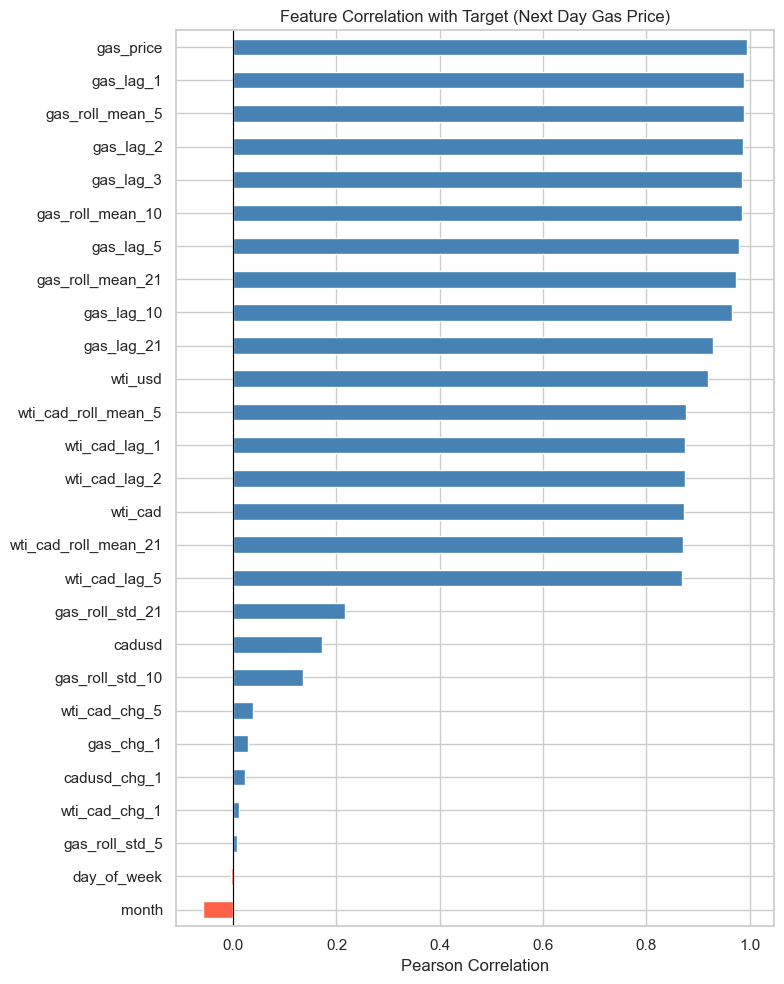

In [11]:
# Correlation of all features with target_price
# We expect gas lags and rolling means to dominate
corr_with_target = (
    df.corr()['target_price']
    .drop(['target_price', 'target_change'])
    .sort_values()
)

plt.figure(figsize=(8, 10))
corr_with_target.plot(
    kind='barh',
    color=['steelblue' if v > 0 else 'tomato' for v in corr_with_target]
)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Target (Next Day Gas Price)')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'feature_correlation.png'), dpi=150)
plt.show()

## 9. Save

In [12]:
df.to_csv(os.path.join(DATA_DIR, 'montreal_gas_ml_ready.csv'), index_label='date')
print(f'Saved: ../Data/montreal_gas_ml_ready.csv  ({len(df):,} rows x {df.shape[1]} columns)')

Saved: ../Data/montreal_gas_ml_ready.csv  (2,523 rows x 29 columns)


## 10. What's in the ML-ready dataset

| Group | Features |
|---|---|
| Raw | `gas_price`, `wti_usd`, `cadusd`, `wti_cad` |
| Gas lags | `gas_lag_1/2/3/5/10/21` |
| WTI lags | `wti_cad_lag_1/2/5` |
| Rolling mean | `gas_roll_mean_5/10/21`, `wti_cad_roll_mean_5/21` |
| Rolling std | `gas_roll_std_5/10/21` |
| Momentum | `wti_cad_chg_1/5`, `gas_chg_1`, `cadusd_chg_1` |
| Calendar | `day_of_week`, `month` |
| **Targets** | `target_price`, `target_change` |

**Next:** Run Notebook 3 to train and evaluate models.